# 04 — Train BulkCell-GNN

Smoke test, stratified train/val split on **bulk** labels, training loop, checkpoint to `DATA_DIR`.


In [2]:
USE_DRIVE = True
from pathlib import Path
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive/BulkCellGNN_data")
else:
    DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR =", DATA_DIR.resolve())


Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/BulkCellGNN_data


In [3]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "torch_geometric", "scikit-learn"])


0

In [5]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/BulkCellGNN_data')

In [6]:
import os, random, sys, json
from pathlib import Path

SEED = 42
random.seed(SEED)
os.environ.setdefault("PYTHONHASHSEED", str(SEED))
import numpy as np
np.random.seed(SEED)
import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import bulkcell_gnn as bcg

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [7]:
bulk_x = torch.tensor(np.load(DATA_DIR / "bulk_expr_sym.npy"), dtype=torch.float32)
cell_x = torch.tensor(np.load(DATA_DIR / "cell_expr.npy"), dtype=torch.float32)
labels = torch.tensor(np.load(DATA_DIR / "bulk_labels.npy"), dtype=torch.long)
cell_types = torch.tensor(np.load(DATA_DIR / "cell_types.npy"), dtype=torch.long)

edge_BB = torch.load(DATA_DIR / "edge_BB.pt", map_location="cpu")
edge_CC = torch.load(DATA_DIR / "edge_CC.pt", map_location="cpu")
edge_BC = torch.load(DATA_DIR / "edge_BC.pt", map_location="cpu")
# Note: edge_B* graphs are built from shared-gene features in notebook 03, while bulk_x/cell_x
# here may be higher-dimensional model inputs. This is intentional.

type_names = json.loads((DATA_DIR / "cell_type_names.json").read_text(encoding="utf-8"))
n_cell_types = len(type_names)
print(bulk_x.shape, cell_x.shape, "n_cell_types", n_cell_types)


torch.Size([536, 22880]) torch.Size([5226, 19545]) n_cell_types 5


In [8]:
# Stratified bulk train/val index split (80/20)
n_bulk = bulk_x.shape[0]
idx = np.arange(n_bulk)
tr_idx, va_idx = train_test_split(idx, test_size=0.2, stratify=labels.numpy(), random_state=SEED)
train_mask = torch.zeros(n_bulk, dtype=torch.bool)
val_mask = torch.zeros(n_bulk, dtype=torch.bool)
train_mask[tr_idx] = True
val_mask[va_idx] = True
print("train", int(train_mask.sum()), "val", int(val_mask.sum()))

np.save(DATA_DIR / "train_mask.npy", train_mask.numpy())
np.save(DATA_DIR / "val_mask.npy", val_mask.numpy())


train 428 val 108


In [9]:
model = bcg.BulkCellGNN(
    n_bulk_genes=bulk_x.shape[1],
    n_cell_genes=cell_x.shape[1],
    d_latent=256,
    n_classes=2,
    n_cell_types=n_cell_types,
    n_layers=2,
    dropout=0.3,
    cell_type_names=type_names,
).to(device)

bulk_x_d, cell_x_d = bulk_x.to(device), cell_x.to(device)
edge_BB_d, edge_CC_d, edge_BC_d = edge_BB.to(device), edge_CC.to(device), edge_BC.to(device)
cell_types_d = cell_types.to(device)

with torch.no_grad():
    out = model(bulk_x_d, cell_x_d, edge_BB_d, edge_CC_d, edge_BC_d, cell_types_d, return_gamma=True)
print({k: tuple(v.shape) for k, v in out.items()})
print("smoke OK")


{'logits': (536, 2), 'cell_recon': (5226, 19545), 'h_B': (536, 256), 'h_C': (5226, 256), 'gamma': (536, 5)}
smoke OK


In [10]:
criterion = bcg.BulkCellLoss(lambda_cls=1.0, lambda_rec=0.5, lambda_aln=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

labels_d = labels.to(device)
train_mask_d, val_mask_d = train_mask.to(device), val_mask.to(device)

best_auc = 0.0
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    out = model(bulk_x_d, cell_x_d, edge_BB_d, edge_CC_d, edge_BC_d, cell_types_d)
    L_total, loss_dict = criterion(
        out["logits"][train_mask_d], labels_d[train_mask_d],
        out["cell_recon"], cell_x_d,
        out["h_B"], out["h_C"], edge_BC_d,
    )
    L_total.backward()
    if epoch == 1:
        no_grad = [name for name, p in model.named_parameters() if p.grad is None]
        if no_grad:
            print("WARNING: parameters with no gradient:", no_grad[:10], "..." if len(no_grad) > 10 else "")
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            outv = model(bulk_x_d, cell_x_d, edge_BB_d, edge_CC_d, edge_BC_d, cell_types_d)
            probs = F.softmax(outv["logits"][val_mask_d], dim=-1)[:, 1].detach().cpu().numpy()
            y = labels_d[val_mask_d].detach().cpu().numpy()
            auc = roc_auc_score(y, probs)
        if auc > best_auc:
            best_auc = float(auc)
            torch.save(model.state_dict(), DATA_DIR / "model_best.pt")
        print(f"epoch {epoch:03d} loss={loss_dict['total']:.4f} cls={loss_dict['classify']:.4f} val_auc={auc:.4f}")

print("best val auc (checkpointed):", best_auc)
if not (DATA_DIR / "model_best.pt").exists():
    torch.save(model.state_dict(), DATA_DIR / "model_best.pt")


epoch 005 loss=248.9185 cls=0.0729 val_auc=0.9925
epoch 010 loss=247.2288 cls=0.0257 val_auc=0.9905
epoch 015 loss=244.0215 cls=0.0143 val_auc=0.9912
epoch 020 loss=238.7766 cls=0.0078 val_auc=0.9878
epoch 025 loss=233.1812 cls=0.0034 val_auc=0.9891
epoch 030 loss=227.8856 cls=0.0017 val_auc=0.9898
epoch 035 loss=222.3754 cls=0.0019 val_auc=0.9898
epoch 040 loss=216.2368 cls=0.0021 val_auc=0.9898
epoch 045 loss=210.1959 cls=0.0022 val_auc=0.9905
epoch 050 loss=204.3563 cls=0.0025 val_auc=0.9925
epoch 055 loss=198.6489 cls=0.0028 val_auc=0.9932
epoch 060 loss=193.4104 cls=0.0033 val_auc=0.9932
epoch 065 loss=188.8604 cls=0.0032 val_auc=0.9939
epoch 070 loss=185.1146 cls=0.0039 val_auc=0.9946
epoch 075 loss=182.1712 cls=0.0033 val_auc=0.9946
epoch 080 loss=179.9084 cls=0.0035 val_auc=0.9946
epoch 085 loss=178.5732 cls=0.0035 val_auc=0.9946
epoch 090 loss=177.8310 cls=0.0035 val_auc=0.9946
epoch 095 loss=177.5598 cls=0.0040 val_auc=0.9946
epoch 100 loss=177.5204 cls=0.0034 val_auc=0.9946


In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── collect per-epoch metrics during training ──────────────────────────────
# Re-run training with logging (or add these lists inside the loop)
# If training already finished, re-run the training cell with this version:

# Replace your training loop cell with this version that logs metrics:
criterion = bcg.BulkCellLoss(lambda_cls=1.0, lambda_rec=0.5, lambda_aln=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

labels_d      = labels.to(device)
train_mask_d  = train_mask.to(device)
val_mask_d    = val_mask.to(device)

# ── logging lists ──────────────────────────────────────────────────────────
log_epoch      = []
log_loss_total = []
log_loss_cls   = []
log_loss_recon = []
log_loss_aln   = []
log_val_auc    = []

best_auc = 0.0
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    out = model(bulk_x_d, cell_x_d, edge_BB_d, edge_CC_d, edge_BC_d, cell_types_d)
    L_total, loss_dict = criterion(
        out["logits"][train_mask_d], labels_d[train_mask_d],
        out["cell_recon"], cell_x_d,
        out["h_B"], out["h_C"], edge_BC_d,
    )
    L_total.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    # log every epoch
    log_epoch.append(epoch)
    log_loss_total.append(loss_dict["total"])
    log_loss_cls.append(loss_dict["classify"])
    log_loss_recon.append(loss_dict["recon"])
    log_loss_aln.append(loss_dict["align"])

    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            outv  = model(bulk_x_d, cell_x_d, edge_BB_d, edge_CC_d, edge_BC_d, cell_types_d)
            probs = F.softmax(outv["logits"][val_mask_d], dim=-1)[:, 1].cpu().numpy()
            y     = labels_d[val_mask_d].cpu().numpy()
            auc   = roc_auc_score(y, probs)
        log_val_auc.append((epoch, auc))
        if auc > best_auc:
            best_auc = float(auc)
            torch.save(model.state_dict(), DATA_DIR / "model_best.pt")
        print(f"epoch {epoch:03d}  loss={loss_dict['total']:.4f}  "
              f"cls={loss_dict['classify']:.4f}  val_auc={auc:.4f}")

print("best val auc:", best_auc)

epoch 005  loss=178.0023  cls=0.0027  val_auc=0.9946
epoch 010  loss=166.3549  cls=0.0048  val_auc=0.9470
epoch 015  loss=153.3676  cls=0.1377  val_auc=0.9361
epoch 020  loss=142.9053  cls=0.0316  val_auc=0.9871
epoch 025  loss=135.0961  cls=0.0063  val_auc=0.9925
epoch 030  loss=130.2917  cls=0.0053  val_auc=0.9932
epoch 035  loss=127.1876  cls=0.0027  val_auc=0.9952
epoch 040  loss=123.7703  cls=0.0015  val_auc=0.9966
epoch 045  loss=121.1115  cls=0.0021  val_auc=0.9980
epoch 050  loss=118.7476  cls=0.0020  val_auc=0.9959
epoch 055  loss=116.6168  cls=0.0040  val_auc=0.9946
epoch 060  loss=115.1359  cls=0.0029  val_auc=0.9925
epoch 065  loss=113.0905  cls=0.0023  val_auc=0.9932
epoch 070  loss=112.0137  cls=0.0027  val_auc=0.9939
epoch 075  loss=111.1667  cls=0.0032  val_auc=0.9946
epoch 080  loss=110.3520  cls=0.0019  val_auc=0.9952
epoch 085  loss=109.4941  cls=0.0027  val_auc=0.9939
epoch 090  loss=109.6359  cls=0.0022  val_auc=0.9946
epoch 095  loss=108.9889  cls=0.0018  val_auc=

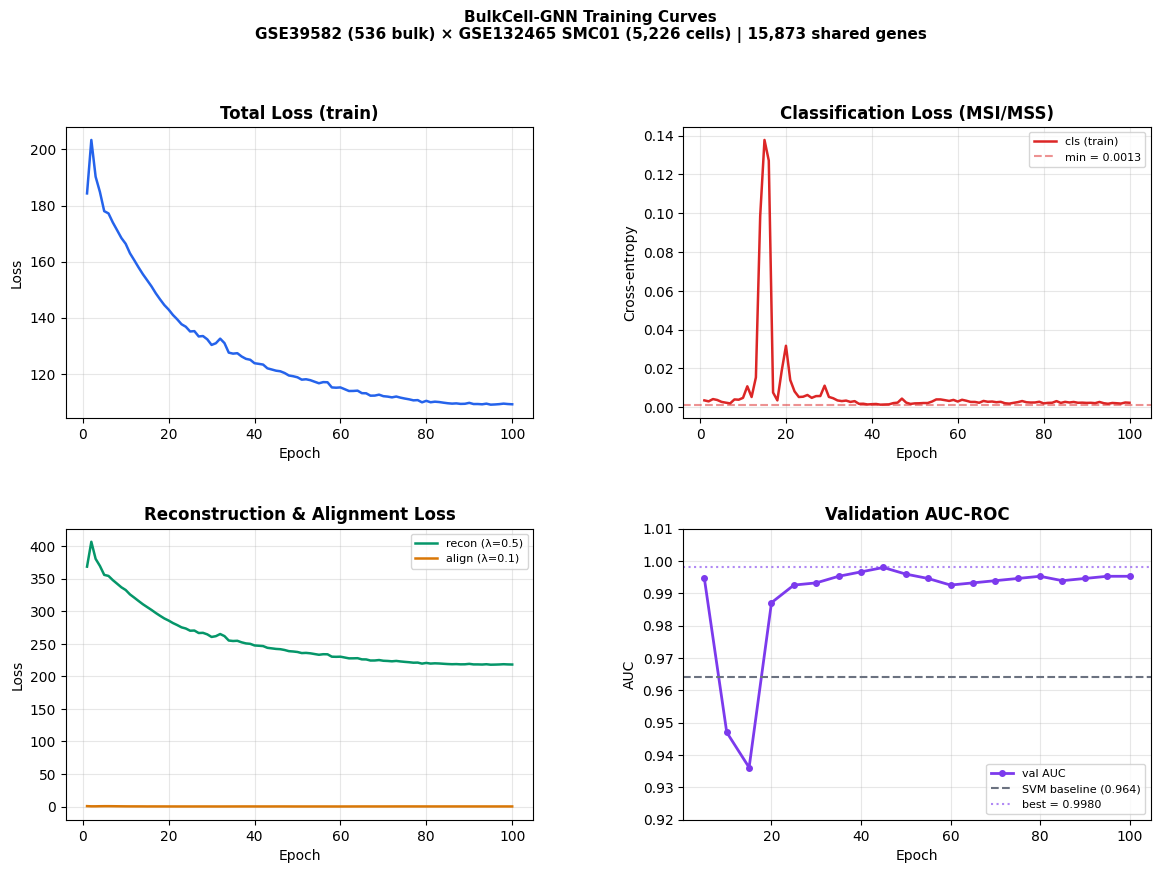

Saved training_curves.png


In [13]:
# ── Loss curves and AUC plot ───────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

epochs = log_epoch
auc_epochs = [e for e, _ in log_val_auc]
auc_vals   = [a for _, a in log_val_auc]

# ── Plot 1: Total loss ─────────────────────────────────────────────────────
ax1.plot(epochs, log_loss_total, color="#2563EB", linewidth=1.8)
ax1.set_title("Total Loss (train)", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

# ── Plot 2: Classification loss ────────────────────────────────────────────
ax2.plot(epochs, log_loss_cls, color="#DC2626", linewidth=1.8, label="cls (train)")
ax2.axhline(y=min(log_loss_cls), color="#DC2626", linestyle="--",
            alpha=0.5, label=f"min = {min(log_loss_cls):.4f}")
ax2.set_title("Classification Loss (MSI/MSS)", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Cross-entropy")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Plot 3: Reconstruction + alignment loss ────────────────────────────────
ax3.plot(epochs, log_loss_recon, color="#059669", linewidth=1.8, label="recon (λ=0.5)")
ax3.plot(epochs, log_loss_aln,   color="#D97706", linewidth=1.8, label="align (λ=0.1)")
ax3.set_title("Reconstruction & Alignment Loss", fontweight="bold")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Loss")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# ── Plot 4: Validation AUC ─────────────────────────────────────────────────
ax4.plot(auc_epochs, auc_vals, color="#7C3AED", linewidth=2.0,
         marker="o", markersize=4, label="val AUC")
ax4.axhline(y=0.964, color="#6B7280", linestyle="--",
            linewidth=1.5, label="SVM baseline (0.964)")
ax4.axhline(y=best_auc, color="#7C3AED", linestyle=":",
            alpha=0.6, label=f"best = {best_auc:.4f}")
ax4.set_ylim(0.92, 1.01)
ax4.set_title("Validation AUC-ROC", fontweight="bold")
ax4.set_xlabel("Epoch")
ax4.set_ylabel("AUC")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

fig.suptitle(
    "BulkCell-GNN Training Curves\n"
    "GSE39582 (536 bulk) × GSE132465 SMC01 (5,226 cells) | 15,873 shared genes",
    fontsize=11, fontweight="bold", y=1.01
)

plt.savefig(DATA_DIR / "training_curves.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved training_curves.png")

In [14]:
# Save final embeddings for evaluation notebook
model.load_state_dict(torch.load(DATA_DIR / "model_best.pt", map_location=device))
model.eval()
with torch.no_grad():
    out = model(bulk_x_d, cell_x_d, edge_BB_d, edge_CC_d, edge_BC_d, cell_types_d)
torch.save(out["h_B"].detach().cpu(), DATA_DIR / "hB_final.pt")
torch.save(out["h_C"].detach().cpu(), DATA_DIR / "hC_final.pt")
print("Saved model_best.pt, hB_final.pt, hC_final.pt")


Saved model_best.pt, hB_final.pt, hC_final.pt
